In [15]:
# 09/09

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [16]:
class SimpleModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleModel, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activition = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activition(x)
        x = self.layer2(x)
        return x

In [17]:
input_size = 10
hidden_size = 20
output_size = 1
batch_size = 32
num_epochs = 5
learning_rate = 0.01
max_norm = 1.0

In [18]:
num_samples = 1000

X = torch.randn(num_samples, input_size)
y = torch.sum(X[:,:5], dim=1, keepdim=True) + torch.randn(num_samples, 1) * 0.1

In [19]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=True)
model = SimpleModel(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),
                      lr=learning_rate)

In [20]:
for epoch in range(num_epochs):
    total_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(),
                            max_norm=max_norm)
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(epoch + 1, avg_loss)
print('학습완료')

with torch.no_grad():
    test_X = torch.randn(5, input_size)
    predictions = model(test_X)
    for i in range(5):
        print(test_X[i][:3], predictions[i].item())

1 5.2649626061320305
2 4.758541509509087
3 4.295970089733601
4 3.712162107229233
5 3.094138018786907
학습완료
tensor([-1.0189, -1.2552, -0.0476]) -1.3765718936920166
tensor([-0.2409, -1.2111, -1.9678]) -0.448056697845459
tensor([-1.4084,  0.1394, -0.3837]) -0.8873623013496399
tensor([-0.5443,  1.9778,  0.5783]) 0.5796259641647339
tensor([-0.0625, -0.0050,  0.9904]) 0.4625456631183624


In [22]:
hidden_size = 20
num_layers = 1
lstm = nn.LSTM(input_size, hidden_size,
               num_layers, batch_first=True)

x = torch.randn(32, 10, input_size)
output, (h_n, c_n) = lstm(x)

print(output.shape)
print(h_n.shape)
print(c_n.shape)

torch.Size([32, 10, 20])
torch.Size([1, 32, 20])
torch.Size([1, 32, 20])


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size,
                 output_size, num_layers=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size = input_size,
                          hidden_size = hidden_size,
                          num_layers = num_layers,
                          bathc_first = True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h_0 = None):
        if h_0 is None:
            h_0 = torch.zeros(self.num_layers, x.size(0),
                              self.hidden_size,
                              device=x.device)
        out, h_n = self.rnn(x, h_0)
        output = self.fc(out)
        return output, h_n

In [27]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

data = [torch.rand(5,10), torch.randn(3,10), torch.randn(7,10)]
lengths = [5,3,7]

padded_seq = torch.nn.utils.rnn.pad_sequence(data, batch_first=True)
print(padded_seq.shape)

packed_seq = pack_padded_sequence(padded_seq,
                                  lengths,
                                  batch_first=True,
                                  enforce_sorted=False)

print(packed_seq)

input_size = 10
hidden_size = 20
rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)

output, hidden = rnn(packed_seq)
print(output)

unpacked_output, unpacked_lengths = pad_packed_sequence(output, batch_first=True)
print(unpacked_output.shape)
print(unpacked_lengths)

torch.Size([3, 7, 10])
PackedSequence(data=tensor([[-0.7838,  1.0825, -0.3693, -1.2357,  0.1491,  0.3583,  0.1979, -1.4134,
         -0.0819,  0.5467],
        [ 0.9362,  0.8489,  0.6935,  0.2652,  0.0781,  0.9819,  0.3362,  0.6709,
          0.3649,  0.3312],
        [ 0.3799, -1.0415,  0.0081,  0.6002,  0.1067, -0.8221, -1.0157, -0.8514,
          0.8717,  0.7740],
        [ 0.9762,  0.0400,  0.2676, -0.2451, -0.2430, -1.3302,  0.3713, -0.1430,
          1.2603,  0.1239],
        [ 0.6780,  0.9626,  0.3812,  0.7166,  0.7013,  0.4201,  0.5995,  0.6661,
          0.9464,  0.3113],
        [-1.2133, -1.1061, -0.8102,  0.7845,  1.5543, -0.0267,  0.0570,  0.6786,
          0.6467,  1.2938],
        [-1.2419,  0.2476,  1.2933, -1.4986, -0.9647, -1.7631, -0.6365,  1.2445,
         -0.3274,  0.2696],
        [ 0.8846,  0.4677,  0.6972,  0.0946,  0.8360,  0.9214,  0.6165,  0.5153,
          0.6305,  0.1051],
        [ 1.2560, -1.6275,  0.2254,  0.6514,  0.2527,  0.3468,  1.5689,  1.6252,
    

In [29]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size,
                 output_size, num_layers=1, dropout=0):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        if isinstance(out, torch.nn.utils.rnn.PackedSequence):
            out, _ = torch.nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        out = self.dropout(out)
        output = self.fc(out)
        return output, hidden

In [31]:
from sklearn.preprocessing import MinMaxScaler

if 'data' in globals() and isinstance(data, list) and all(isinstance(item, torch.Tensor) for item in data):
    padded_data = torch.nn.utils.rnn.pad_sequence(data, batch_first=True)
    data_concatenated = padded_data.view(-1, padded_data.shape[-1]).numpy()
elif 'data' in globals() and isinstance(data, np.ndarray):
    data_concatenated = data
else:
    print('Warning')
    data_concatenated = np.random.randn(100, 10)

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_concatenated)

def create_window(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i+window_size)])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

window_size = 10
horizon = 1

X, y = create_window(data_normalized, window_size, horizon)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
b_train, b_test = y[:split_idx], y[split_idx:]

적용된 폰트: ['Malgun Gothic']


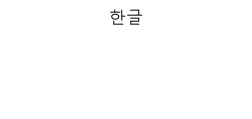

In [33]:
import platform
from matplotlib import font_manager
import matplotlib.pyplot as plt

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])
plt.figure(figsize=(3,1))
plt.title('한글')
plt.axis('off')
plt.show()

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

In [42]:
ticker = '005930.KS'
start_date = '2018-01-01'
end_date = '2023-01-01'
stock_data = yf.download(ticker,
                         start=start_date,
                         end=end_date)

df = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2018-01-02,41451.033091,41467.168175,40966.980544,41160.601562,8474250
2018-01-03,42386.874169,42403.009256,41483.309284,41644.660156,10013500
2018-01-04,42048.048190,42096.453465,40854.051427,41209.023438,11695450
2018-01-05,41386.496614,42048.035156,41305.821182,42048.035156,9481150
2018-01-08,42273.933884,42370.744419,41547.854867,41967.367188,8383650


In [44]:
df = df.dropna()
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df), columns=df.columns, index=df.index)

In [45]:
def create_sequence(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].values
        y = data.iloc[i + seq_length]['Close']
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys).reshape(-1, 1)

seq_length = 20

X, y = create_sequence(df_scaled, seq_length)
print(X.shape, y.shape)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

(1210, 20, 5) (1210, 1)


In [47]:
class StockModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super(StockModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:,-1,:]
        out = self.dropout(last_time_step)
        predictions = self.fc(out)
        return predictions

input_size = X_train.shape[2]
hidden_size = 64
num_layers = 2
model = StockModel(input_size, hidden_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
batch_size = 32
train_losses = []
val_losses = []
best_val_loss = float('inf')

In [50]:
for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i + batch_size]
        batch_y = y_train[i:i + batch_size]

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm(model.parameters(), max_norm = 1.0)
        optimizer.step()
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train)
        train_loss = criterion(train_preds, y_train).item()
        train_losses.append(train_loss)
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
        val_losses.append(val_loss)
    print(epoch + 1, train_loss, val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_stock_model.pt')

model.load_state_dict(torch.load('best_stock_model.pt'))
model.eval()
with torch.no_grad():
    test_predictions = model(X_test)
test_dates = df.index[train_size + val_size + seq_length:]

def inverse_transform_close(data):
    dummy = np.zeros((len(data), 5))
    dummy[:,3] = data.flatten()
    return scaler.inverse_transform(dummy)[:,3]

y_test_orig = inverse_transform_close(y_test.numpy())
test_predictions_orig = inverse_transform_close(test_predictions.numpy())

mse = mean_squared_error(y_test_orig, test_predictions_orig)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_orig, test_predictions_orig)
r2 = r2_score(y_test_orig, test_predictions_orig)

print(mse)
print(rmse)
print(mae)
print(r2)

C:\Users\KDS10\AppData\Local\Temp\ipykernel_44312\3788705584.py:11: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  nn.utils.clip_grad_norm(model.parameters(), max_norm = 1.0)


1 0.0006158087053336203 0.0006721902173012495
2 0.0005686533404514194 0.0006913473480381072
3 0.0005559491110034287 0.000948534463532269
4 0.0009324251441285014 0.0030247585382312536
5 0.0007153920014388859 0.000657568802125752
6 0.000701826938893646 0.0007477233302779496
7 0.002430722815915942 0.003355593653395772
8 0.001394129591062665 0.0018332295585423708
9 0.0013519702479243279 0.000948582252021879
10 0.0075375777669250965 0.011430226266384125
11 0.0034143049269914627 0.012267975136637688
12 0.0039532664231956005 0.000659847806673497
13 0.0010833177948370576 0.0009248367859981954
14 0.0012485029874369502 0.001982741989195347
15 0.003678400069475174 0.009678258560597897
16 0.0020321279298514128 0.0016985689289867878
17 0.0007714532548561692 0.0006265538977459073
18 0.0015927166678011417 0.0028586655389517546
19 0.0009464921895414591 0.002114347880706191
20 0.0010998984798789024 0.005623715929687023
21 0.001502015395089984 0.0007398002780973911
22 0.0008968086913228035 0.00065494293

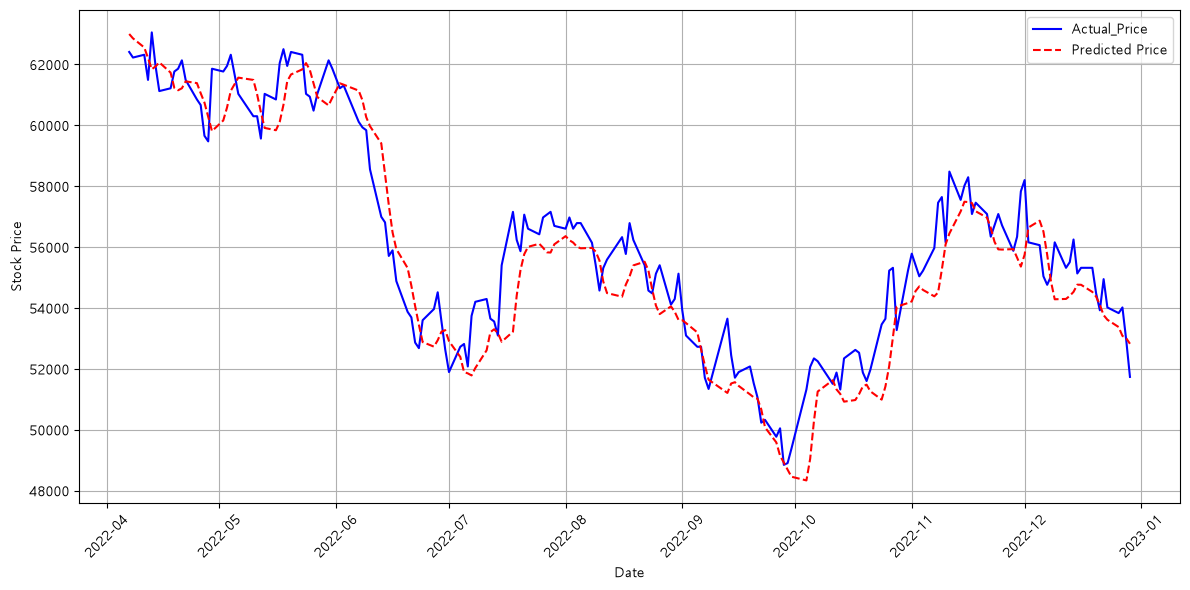

In [49]:
plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test_orig, 'b-', label='Actual_Price')
plt.plot(test_dates, test_predictions_orig, 'r--', label='Predicted Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
from torch.nn.utils.rnn import pad_sequence

def build_vocab(tokenized_texts, min_freq=1):
    word_counts = {}
    for text in tokenized_texts:
        for token in text:
            word_counts[token] = word_counts.get(token, 0) + 1
        vocab = {'<pad>': 0,
                 '<unk>': 1}
        idx = 2
        for word, count in word_counts.items():
            if count >= min_freq:
                vocab[word] = idx
                idx += 1
        return vocab

def text_to_indices(tokenized_text, vocab):
    return [vocab.get(token, vocab['<unk>']) for token in tokenized_text]

sequences = [torch.tensor([1,2,3]), torch.tensor([4,5]), torch.tensor([6,7,8,9])]
padded_seq = pad_sequence(sequences, batch_first=True)
print(padded_seq)

mask = (padded_seq != 0).float()

tensor([[1, 2, 3, 0],
        [4, 5, 0, 0],
        [6, 7, 8, 9]])


In [55]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim,
                 hidden_dim, output_dim, n_layers=1,
                 bidirectional=False, dropout=0.5, pad_idx=0):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size,
                                      embedding_dim,
                                      padding_idx=pad_idx)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim,
                            output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, text_length):
        embedded = self.embedding(text)
        packed_embedded = nn.utils.rnn.pack_sequence(embedded,
                                                     text_length.cpu(),
                                                     batch_first=True,
                                                     enforce_sorted=False)
        packed_output, (hidden, _) = self.rnn(packed_embedded)

        if self.rnn.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2,:,:],
                                             hidden[-1,:,:]),
                                             dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
        return self.fc(hidden)